In [5]:
import pandas as pd
import numpy as np
import anc2vec

DEBUG = False

embeddings = anc2vec.get_embeddings()

def merge_embeddings(go_list, go_to_embeddings):
    """
    Merge embeddings with sum
    """
    embeddings = [go_to_embeddings[g.strip()] for g in go_list if g in go_to_embeddings]
    
    if not embeddings:  # Se la lista è vuota, ritorna un embedding nullo della stessa dimensione
        return np.zeros_like(next(iter(go_to_embeddings.values()))).tolist()

    return np.sum(embeddings, axis=0).tolist()  # Somma dei vettori

def embed_gos(nodes_path, sep=','):
    """
    Associates an anc2vec ambedding to every entry of a dataframe.
    """
    if type(nodes_path) is pd.core.frame.DataFrame:
        nodes_df = nodes_path.copy()[['STRING', 'Gene Ontology IDs']]
    else:
        nodes_df = pd.read_csv(nodes_path, sep=sep)[['STRING', 'Gene Ontology IDs']]
    unique_go_ids = set(id.strip() for ids in nodes_df['Gene Ontology IDs'].str.split(';') for id in ids)
    go_to_embeddings = {go:embeddings[go] for go in unique_go_ids if go in embeddings}

    nodes_df['Gene Ontology IDs'] = nodes_df['Gene Ontology IDs'].apply(
        lambda x: merge_embeddings([go.strip() for go in x.split(';')], go_to_embeddings)
    )

    nodes_df['STRING'] = nodes_df['STRING'].apply(
        lambda x: x.split(';')[0]
    )

    nodes_df.columns = ['STRING_id', 'GO_embeddings']
    return nodes_df

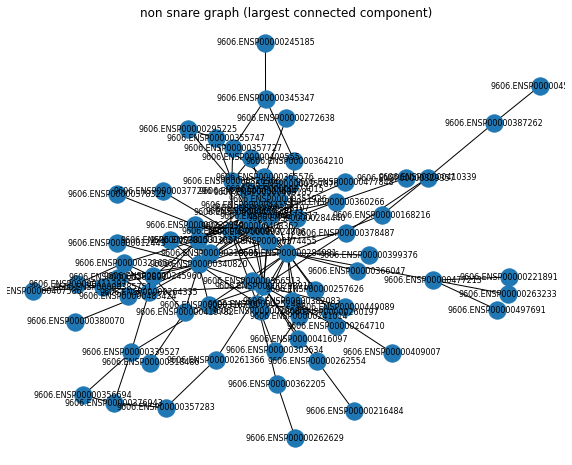

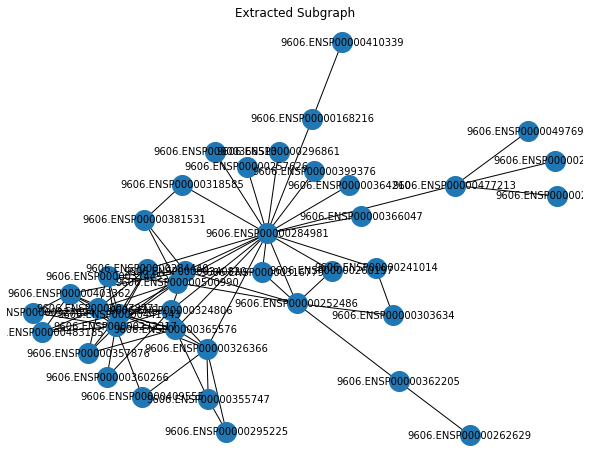

Nodi:  40
Archi:  86


In [6]:
"""
Non-Snare class is made using a biologically meaningful subset of the AD PPI.
"""

# 1 = SNARE | 0 = NON SNARE

import sys

NODES_FILE = '../sources/snare_prediction/AD_nodes.tsv'
EDGES_FILE = '../sources/snare_prediction/AD_edges.tsv'
SNARE_FILE = '../sources/snare_prediction/snare_proteins.tsv'

nodes_df = pd.read_csv(NODES_FILE, sep='\t', usecols=['Entry', 'Gene Ontology IDs', 'STRING', 'Entry Name'])

snare_df = pd.read_csv(SNARE_FILE, 
                       sep='\t', 
                       usecols=['Entry', 'Gene Ontology IDs', 'STRING', 'Entry Name'])
snare_ids = set(snare_df['STRING'].to_list())
mask = nodes_df['STRING'].isin(snare_ids)

if len(nodes_df[mask]) != 0:
    print("Overlap found", file=sys.stderr)
    # print(nodes_df[mask])

# Embedding
non_snare_all_df = embed_gos(NODES_FILE, sep='\t')
non_snare_all_df['LABEL'] = 0

non_snare_edges_all_df = pd.read_csv(EDGES_FILE, sep='\t', usecols=['node1_string_id', 'node2_string_id'])
non_snare_all_df

# Undersampling
import networkx as nx

# 3.1 - Make an empty graph with non snare nodes
G = nx.Graph()
G.add_nodes_from(non_snare_all_df['STRING_id'])
G.add_edges_from(non_snare_edges_all_df[['node1_string_id', 'node2_string_id']].values)
feature_dict = non_snare_all_df.set_index('STRING_id').to_dict(orient='index')

# 3.2 - Add attributes
for node in G.nodes():
    if node in feature_dict:
        G.nodes[node].update(feature_dict[node])


# 3.2 - Extract the largest connected component and plot
connected_components = nx.connected_components(G)
largest_component_nodes = max(connected_components, key=len)
G = G.subgraph(largest_component_nodes)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.title('non snare graph (largest connected component)')
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=300, font_size=8)
plt.show()

# 3.3 - subgraph sampling
import random

def random_walk_restart(G, n_nodes, restart_prob=0.15):
    start_node = random.choice(list(G.nodes))
    current = start_node
    visited = {current}
    
    while len(visited) < n_nodes:
        if random.random() < restart_prob:
            current = start_node
        else:
            neighbors = list(G.neighbors(current))
            if neighbors:
                current = random.choice(neighbors)
                visited.add(current)
            else:
                current = start_node
    
    return G.subgraph(visited).copy()

G_sub = random_walk_restart(G, 40)

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G_sub)
nx.draw(G_sub, pos, with_labels=True, node_size=400, font_size=10)
plt.title(f"Extracted Subgraph")
plt.show()

# 3.4 - Make dataframe out of graph nodes

import pandas as pd

def extract_nodes_edges(G):
    nodes_data = []
    for node, attr in G.nodes(data=True):
        attr_copy = attr.copy()
        attr_copy['STRING_id'] = node
        nodes_data.append(attr_copy)

    nodes_df = pd.DataFrame(nodes_data)
    
    edges_data = []
    for u, v, attr in G.edges(data=True):
        attr_copy = attr.copy()
        attr_copy['source'] = u
        attr_copy['target'] = v
        edges_data.append(attr_copy)

    edges_df = pd.DataFrame(edges_data)
    
    return nodes_df, edges_df

sampled_nodes_df, sampled_edges_df = extract_nodes_edges(G_sub)

print("Nodi: ", len(sampled_nodes_df))
print("Archi: ", len(sampled_edges_df))


In [7]:
# Final preprocessing steps and training data output

snare_nodes_df = embed_gos(SNARE_FILE, sep='\t')
snare_nodes_df['LABEL'] = 1
snare_edges_df = pd.read_csv('../sources/snare_prediction/snare_edges.tsv', sep='\t', usecols=['node1_string_id', 'node2_string_id'])


sampled_edges_df = sampled_edges_df.rename(columns={'source': 'node1_string_id', 'target': 'node2_string_id'})

classification_nodes = pd.concat([sampled_nodes_df, snare_nodes_df])
classification_nodes = classification_nodes.reindex(columns=['STRING_id', 'GO_embeddings', 'LABEL'])
classification_edges = pd.concat([sampled_edges_df, snare_edges_df])

# DEBUG plotting
if DEBUG:
    import networkx as nx

    G = nx.Graph()
    G.add_nodes_from(classification_nodes['STRING_id'])
    G.add_edges_from(classification_edges[['node1_string_id', 'node2_string_id']].values)

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 8))
    plt.title('DEBUG')
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_size=300, font_size=8)
    plt.show()

classification_nodes = classification_nodes.reset_index(drop=True)
string_to_id = pd.Series(classification_nodes.index, index=classification_nodes['STRING_id']).to_dict()

classification_edges['node1_id'] = classification_edges['node1_string_id'].map(string_to_id)
classification_edges['node2_id'] = classification_edges['node2_string_id'].map(string_to_id)

# Output

classification_nodes.to_csv('../pre_processing_output/snare_classification_nodes.csv')
classification_edges.to_csv('../pre_processing_output/snare_classification_edges.csv')

